In [31]:
import sys 
sys.path.append("../../src")
from common_imports import *
import kibble_zurek as kz
import time_evolved_z_correlators as tz

In [215]:
def pair_antisym(l, state):
    u, v, k = state
    term = np.exp(1j*k*l)*np.conj(u)*np.conj(v) - np.conj(np.exp(1j*k*l)*np.conj(u)*np.conj(v) )
    return 2j*np.mean(term)

def alpha(l,h):
    if h**2 <1:
        return -1/8* h**(l-1)
    else:
        return -1/8*h**(-l-1)
pair_antisym(1,states[10])

np.complex128(0.03806478742241334+0j)

In [221]:
tau = 10
times = np.linspace(-tau,2*tau,40)
g= 1-times/tau
states = [kz.state(200,tau,t) for t in times]


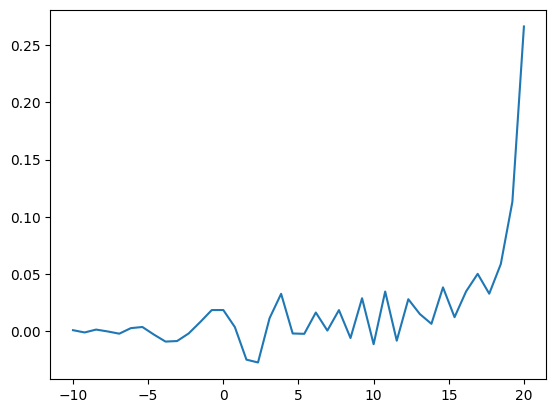

In [222]:
dat=[]
for i,t in enumerate(times):
    gi = g[i]
    s= states[i]
    dat.append( sum([alpha(l,gi)*pair_antisym(l,s) for l in range(1,200)] ))
plot(times,dat)

In [191]:
tau = 100
times = np.linspace(-5*tau,7*tau,50)
g= 1-times/tau
states = [kz.state(200,tau,t) for t in times]


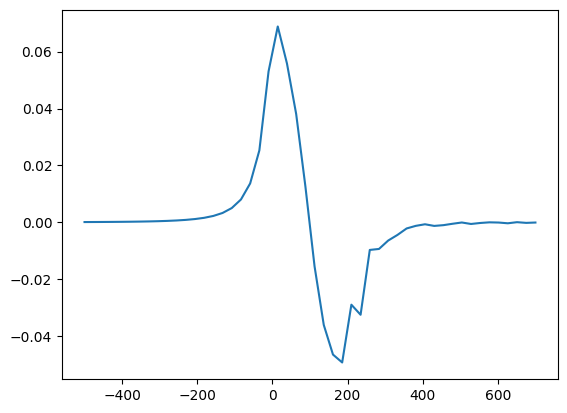

In [192]:
dat=[]
for i,t in enumerate(times):
    gi = g[i]
    s= states[i]
    dat.append( sum([alpha(l,gi)*pair_antisym(l,s) for l in range(1,200)] ))
plot(times,dat)

100%|██████████| 100/100 [00:09<00:00, 10.70it/s]


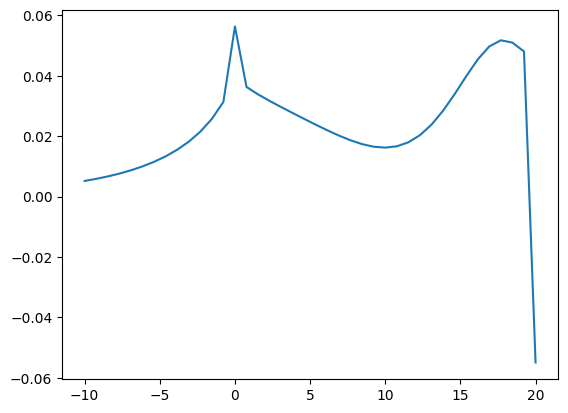

In [347]:
dat=[]
for i,t in enumerate(times):
    gi = g[i]
    s= states[i]
    dat.append( sum([alpha(l,gi)*pair_antisym(l,s) for l in range(1,200)] ))
plot(times,dat)

[]

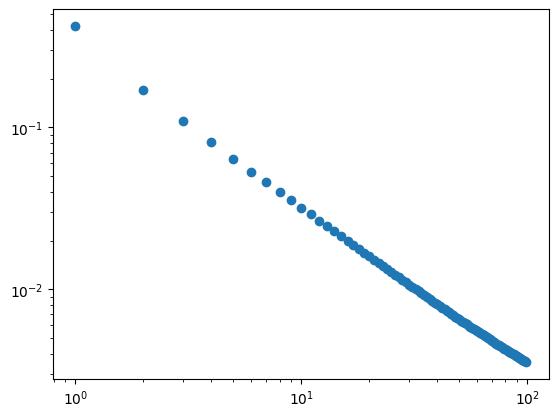

In [348]:
import kblock_ising_model as kb

k = kb.k_vals(400)
g= 1

U = kb.U(k,g)
Ls = np.arange(1,100)

dat =[kb.cc(U,k,l)-kb.aa(U,k,l) for l in Ls]
scatter(Ls,dat)
#lot(Ls,Ls**-1.)
loglog()

In [355]:
def cc(l,state):
    u,v,k= state

    amp = np.conj(u) * v
    phase = np.exp(-1j * k * l)
    return -1j * np.mean(amp * phase)

def aa(l,state):
    u,v,k= state
    p = exp(-1j*k*l)
    amp = v*np.conj(u)
    return 1j*np.mean(amp*p)

taus = np.logspace(-2,3,100)
g= 1-times/tau
states = [kz.state(100,tau,tau) for tau in tqdm(taus)]


100%|██████████| 100/100 [00:20<00:00,  4.95it/s]


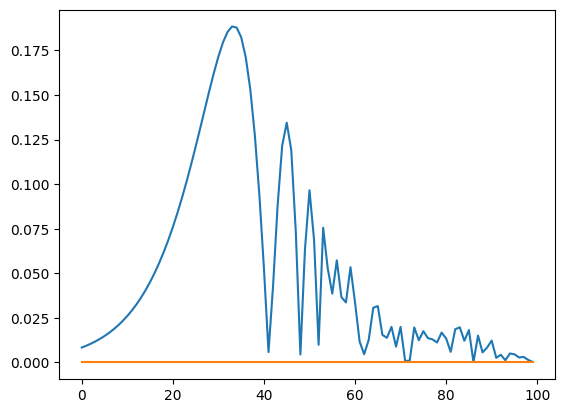

In [357]:
Gs = array([np.imag(cc(1,s)-aa(-1,s)) for s in states])
plot(np.abs(Gs))
Gs = [np.imag(cc(50,s)-aa(-50,s)) for s in states]
plot(Gs)

np.complex128(0.6632495979977502-0.7384475886658266j)